In [1]:
from pathlib import Path
import os
import json
import random
import platform
import warnings
from contextlib import nullcontext

PROJECT_ROOT_CANDIDATE = Path(r"D:\Project\Leeds\Msc Project")
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents, PROJECT_ROOT_CANDIDATE):
        if (candidate / "Models").exists() and (candidate / "Dataset source").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing Models and Dataset source.")

BASE_DIR = find_project_root(Path.cwd())

os.environ.setdefault("HF_HOME", str(BASE_DIR / "local_artifacts" / "cache" / "huggingface"))
os.environ.setdefault("TRANSFORMERS_CACHE", str(BASE_DIR / "local_artifacts" / "cache" / "huggingface" / "transformers"))
os.environ.setdefault("HF_DATASETS_CACHE", str(BASE_DIR / "local_artifacts" / "cache" / "huggingface" / "datasets"))
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import datasets
from datasets import Dataset, DatasetDict
import transformers
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
    set_seed,
)
from transformers.utils import logging as hf_logging
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
hf_logging.set_verbosity_error()

SEED = 42
SHOW_PROGRESS = False

if SHOW_PROGRESS:
    datasets.enable_progress_bar()
else:
    datasets.disable_progress_bar()

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True

DATA_DIR = BASE_DIR / "Dataset source" / "training" / "multilingual"
TRAIN_PATH = DATA_DIR / "multilingual_sms_train.csv"
VALIDATION_PATH = DATA_DIR / "multilingual_sms_validation.csv"
TEST_PATH = DATA_DIR / "multilingual_sms_test.csv"

BASE_MODEL_PATH = BASE_DIR / "local_artifacts" / "huggingface" / "models" / "finetuned_xlm_roberta_sms_spam"
FALLBACK_MODEL_ID = "kauffinger/xlm-roberta-base-finetuned-enron"

MODEL_OUTPUT_DIR = BASE_DIR / "local_artifacts" / "huggingface" / "models" / "finetuned_xlm_roberta_multilingual_sms_spam"
UI_MODEL_OUTPUT_DIR = BASE_DIR / "Models" / "multilingual_transformer_spam_classifier"
RUN_DIR = BASE_DIR / "local_artifacts" / "huggingface" / "runs" / "multilingual_sms_xlm_roberta"
BEST_CHECKPOINT_DIR = RUN_DIR / "best_checkpoint"

LABEL2ID = {"ham": 0, "spam": 1}
ID2LABEL = {0: "ham", 1: "spam"}
LANGUAGE_NAMES = {
    "ar": "Arabic",
    "de": "German",
    "en": "English",
    "es": "Spanish",
    "fr": "French",
    "zh": "Chinese",
}

MAX_LENGTH = 192
BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0

assert BASE_MODEL_PATH.resolve() != MODEL_OUTPUT_DIR.resolve(), "Output path must not equal the existing English model path."

print(f"Project root: {BASE_DIR}")
print(f"Base model: {BASE_MODEL_PATH if BASE_MODEL_PATH.exists() else FALLBACK_MODEL_ID}")
print(f"New multilingual output: {MODEL_OUTPUT_DIR}")
print(f"UI model output: {UI_MODEL_OUTPUT_DIR}")
print(f"Device: {'cuda - ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")
print(f"Python {platform.python_version()} | torch {torch.__version__} | transformers {transformers.__version__}")


c:\ProgramData\anaconda3\envs\py310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\ProgramData\anaconda3\envs\py310\lib\site-packages\transformers\utils\hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Project root: d:\Project\Leeds\Msc Project
Base model: d:\Project\Leeds\Msc Project\local_artifacts\huggingface\models\finetuned_xlm_roberta_sms_spam
New multilingual output: d:\Project\Leeds\Msc Project\local_artifacts\huggingface\models\finetuned_xlm_roberta_multilingual_sms_spam
UI model output: d:\Project\Leeds\Msc Project\Models\multilingual_transformer_spam_classifier
Device: cuda - NVIDIA GeForce RTX 5070
Python 3.10.19 | torch 2.9.1+cu128 | transformers 4.39.3


In [2]:
def load_split(path: Path, split_name: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing split file: {path}")

    df = pd.read_csv(path)
    required = {"text", "label", "language_code"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {sorted(missing)}")

    df = df.copy()
    if "language" not in df.columns:
        df["language"] = df["language_code"]

    df["text"] = df["text"].astype(str).str.strip()
    df["label"] = df["label"].astype(str).str.strip().str.lower()
    df["language_code"] = df["language_code"].astype(str).str.strip().str.lower()
    df["language"] = df["language"].astype(str).str.strip()

    before = len(df)
    df = df[df["text"].ne("")]
    df = df[df["label"].isin(LABEL2ID)]
    df = df[df["language_code"].ne("")]
    after = len(df)
    if before != after:
        print(f"{split_name}: dropped {before - after} invalid rows")

    df["label_id"] = df["label"].map(LABEL2ID).astype(int)
    df["split"] = split_name
    return df.reset_index(drop=True)

train_df = load_split(TRAIN_PATH, "train")
validation_df = load_split(VALIDATION_PATH, "validation")
test_df = load_split(TEST_PATH, "test")
all_df = pd.concat([train_df, validation_df, test_df], ignore_index=True)

rows_df = pd.DataFrame({
    "split": ["train", "validation", "test", "total"],
    "rows": [len(train_df), len(validation_df), len(test_df), len(all_df)],
})
display(rows_df)

split_summary = (
    all_df.groupby(["split", "language_code", "label"])
    .size()
    .rename("count")
    .reset_index()
    .pivot_table(index=["split", "language_code"], columns="label", values="count", fill_value=0)
    .reset_index()
)
split_summary["total"] = split_summary.get("ham", 0) + split_summary.get("spam", 0)
split_summary["spam_rate"] = split_summary.get("spam", 0) / split_summary["total"]
display(split_summary.sort_values(["split", "language_code"]))


,split,rows
0,train,22754
1,validation,2844
2,test,2846
3,total,28444


label,split,language_code,ham,spam,total,spam_rate
0,test,ar,301.0,16.0,317.0,0.050473
1,test,de,344.0,36.0,380.0,0.094737
2,test,en,845.0,148.0,993.0,0.149043
3,test,es,364.0,26.0,390.0,0.066667
4,test,fr,363.0,24.0,387.0,0.062016
5,test,zh,334.0,45.0,379.0,0.118734
6,train,ar,2404.0,123.0,2527.0,0.048674
7,train,de,2751.0,283.0,3034.0,0.093276
8,train,en,6760.0,1185.0,7945.0,0.149150
9,train,es,2910.0,210.0,3120.0,0.067308


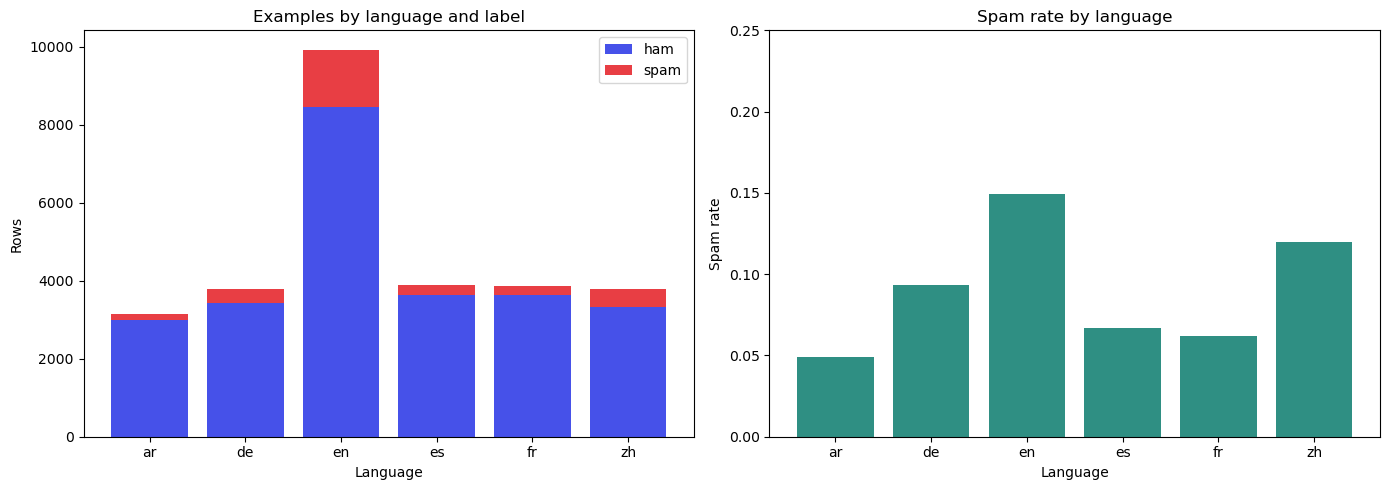

In [3]:
import matplotlib.pyplot as plt

language_order = [code for code in LANGUAGE_NAMES if code in set(all_df["language_code"])]
pivot_counts = (
    all_df.groupby(["language_code", "label"])
    .size()
    .rename("count")
    .reset_index()
    .pivot(index="language_code", columns="label", values="count")
    .reindex(language_order)
    .fillna(0)
)
for label in ["ham", "spam"]:
    if label not in pivot_counts.columns:
        pivot_counts[label] = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(language_order, pivot_counts["ham"], label="ham", alpha=0.85, color="#2632E6")
axes[0].bar(language_order, pivot_counts["spam"], label="spam", alpha=0.85, color="#E51C23", bottom=pivot_counts["ham"])
axes[0].set_title("Examples by language and label")
axes[0].set_xlabel("Language")
axes[0].set_ylabel("Rows")
axes[0].legend()

spam_rate = all_df.groupby("language_code")["label_id"].mean().reindex(language_order)
axes[1].bar(language_order, spam_rate, color="#2F8F83")
axes[1].set_title("Spam rate by language")
axes[1].set_xlabel("Language")
axes[1].set_ylabel("Spam rate")
axes[1].set_ylim(0, max(0.25, float(spam_rate.max()) * 1.2))

plt.tight_layout()
plt.show()


In [4]:
model_source = str(BASE_MODEL_PATH) if BASE_MODEL_PATH.exists() else FALLBACK_MODEL_ID
local_files_only = BASE_MODEL_PATH.exists()

tokenizer = AutoTokenizer.from_pretrained(model_source, local_files_only=local_files_only)

def to_hf_dataset(df: pd.DataFrame) -> Dataset:
    columns = ["text", "label", "label_id", "language", "language_code"]
    return Dataset.from_pandas(df[columns], preserve_index=False)

raw_datasets = DatasetDict({
    "train": to_hf_dataset(train_df),
    "validation": to_hf_dataset(validation_df),
    "test": to_hf_dataset(test_df),
})

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

tokenized_datasets = raw_datasets.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text", "label", "language", "language_code"],
)
tokenized_datasets = tokenized_datasets.rename_column("label_id", "labels")

torch_columns = list(dict.fromkeys(tokenizer.model_input_names + ["labels"]))
tokenized_datasets.set_format(type="torch", columns=torch_columns)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_loader = DataLoader(tokenized_datasets["train"], batch_size=BATCH_SIZE, shuffle=True, collate_fn=data_collator)
validation_loader = DataLoader(tokenized_datasets["validation"], batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=data_collator)
test_loader = DataLoader(tokenized_datasets["test"], batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=data_collator)

token_lengths = np.array([len(ids) for ids in tokenized_datasets["train"]["input_ids"]])
print(
    f"Tokenized splits: train={len(train_df)}, validation={len(validation_df)}, test={len(test_df)} | "
    f"train token length median={np.median(token_lengths):.0f}, p95={np.percentile(token_lengths, 95):.0f}"
)


Tokenized splits: train=22754, validation=2844, test=2846 | train token length median=18, p95=51


In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_source,
    num_labels=2,
    label2id=LABEL2ID,
    id2label=ID2LABEL,
    local_files_only=local_files_only,
)
model.config.label2id = LABEL2ID
model.config.id2label = ID2LABEL

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_counts = train_df["label_id"].value_counts().sort_index()
class_weights = len(train_df) / (len(LABEL2ID) * train_counts)
class_weights = torch.tensor([class_weights.get(0, 1.0), class_weights.get(1, 1.0)], dtype=torch.float, device=device)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
num_training_steps = len(train_loader) * NUM_EPOCHS
num_warmup_steps = int(num_training_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

def amp_context():
    return torch.autocast(device_type="cuda", dtype=torch.float16) if use_amp else nullcontext()

def batch_to_device(batch):
    return {key: value.to(device) for key, value in batch.items()}

def compute_metrics_from_arrays(labels: np.ndarray, preds: np.ndarray, prefix: str | None = None) -> dict:
    accuracy = accuracy_score(labels, preds)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    spam_precision, spam_recall, spam_f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=LABEL2ID["spam"], zero_division=0
    )
    metrics = {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "spam_precision": spam_precision,
        "spam_recall": spam_recall,
        "spam_f1": spam_f1,
    }
    return {f"{prefix}_{key}": value for key, value in metrics.items()} if prefix else metrics

@torch.inference_mode()
def evaluate_model(data_loader: DataLoader, split_name: str):
    model.eval()
    losses = []
    logits_chunks = []
    label_chunks = []

    for batch in tqdm(data_loader, desc=f"Evaluating {split_name}", disable=not SHOW_PROGRESS, leave=False):
        batch = batch_to_device(batch)
        labels = batch.pop("labels")
        with amp_context():
            outputs = model(**batch)
            loss = loss_fn(outputs.logits, labels)
        losses.append(float(loss.detach().cpu()))
        logits_chunks.append(outputs.logits.detach().float().cpu().numpy())
        label_chunks.append(labels.detach().cpu().numpy())

    logits = np.concatenate(logits_chunks, axis=0)
    labels = np.concatenate(label_chunks, axis=0)
    preds = np.argmax(logits, axis=1)
    metrics = compute_metrics_from_arrays(labels, preds, prefix=split_name)
    metrics[f"{split_name}_loss"] = float(np.mean(losses))
    return metrics, logits, labels, preds

class_weight_df = pd.DataFrame({
    "label": ["ham", "spam"],
    "train_rows": [int(train_counts.get(0, 0)), int(train_counts.get(1, 0))],
    "loss_weight": class_weights.detach().cpu().numpy(),
})
display(class_weight_df)


,label,train_rows,loss_weight
0,ham,20398,0.557751
1,spam,2356,4.828948


## fine-tune


In [6]:
RUN_DIR.mkdir(parents=True, exist_ok=True)
BEST_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

history = []
best_validation_macro_f1 = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_losses = []
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", disable=not SHOW_PROGRESS, leave=False)
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(progress_bar, start=1):
        batch = batch_to_device(batch)
        labels = batch.pop("labels")

        with amp_context():
            outputs = model(**batch)
            loss = loss_fn(outputs.logits, labels)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()

        scheduler.step()
        optimizer.zero_grad(set_to_none=True)
        epoch_losses.append(float(loss.detach().cpu()))

        if SHOW_PROGRESS and step % 20 == 0:
            progress_bar.set_postfix(loss=np.mean(epoch_losses[-20:]))

    train_loss = float(np.mean(epoch_losses))
    validation_metrics, _, _, _ = evaluate_model(validation_loader, "validation")
    row = {"epoch": epoch, "train_loss": train_loss, **validation_metrics}
    history.append(row)

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_accuracy={validation_metrics['validation_accuracy']:.4f} | "
        f"val_macro_f1={validation_metrics['validation_macro_f1']:.4f} | "
        f"val_spam_f1={validation_metrics['validation_spam_f1']:.4f}"
    )

    if validation_metrics["validation_macro_f1"] > best_validation_macro_f1:
        best_validation_macro_f1 = validation_metrics["validation_macro_f1"]
        model.save_pretrained(BEST_CHECKPOINT_DIR)
        tokenizer.save_pretrained(BEST_CHECKPOINT_DIR)

history_df = pd.DataFrame(history)
display(history_df[["epoch", "train_loss", "validation_accuracy", "validation_macro_f1", "validation_spam_f1", "validation_loss"]])

model = AutoModelForSequenceClassification.from_pretrained(
    str(BEST_CHECKPOINT_DIR),
    num_labels=2,
    label2id=LABEL2ID,
    id2label=ID2LABEL,
    local_files_only=True,
)
model.to(device)
model.config.label2id = LABEL2ID
model.config.id2label = ID2LABEL
print(f"Best validation macro F1: {best_validation_macro_f1:.4f}")


Epoch 1/3 | train_loss=0.1353 | val_accuracy=0.9965 | val_macro_f1=0.9906 | val_spam_f1=0.9832
Epoch 2/3 | train_loss=0.0432 | val_accuracy=0.9947 | val_macro_f1=0.9855 | val_spam_f1=0.9740
Epoch 3/3 | train_loss=0.0102 | val_accuracy=0.9961 | val_macro_f1=0.9896 | val_spam_f1=0.9814


,epoch,train_loss,validation_accuracy,validation_macro_f1,validation_spam_f1,validation_loss
0,1,0.135290,0.996484,0.990601,0.983165,0.021284
1,2,0.043167,0.994726,0.985534,0.974003,0.038985
2,3,0.010178,0.996132,0.989615,0.981387,0.033863


Best validation macro F1: 0.9906


## evaluate

In [7]:
validation_metrics, validation_logits, validation_true_ids, validation_pred_ids = evaluate_model(validation_loader, "validation")
test_metrics, test_logits, true_ids, pred_ids = evaluate_model(test_loader, "test")

metrics_table = pd.DataFrame([
    {
        "split": "validation",
        "accuracy": validation_metrics["validation_accuracy"],
        "macro_f1": validation_metrics["validation_macro_f1"],
        "spam_precision": validation_metrics["validation_spam_precision"],
        "spam_recall": validation_metrics["validation_spam_recall"],
        "spam_f1": validation_metrics["validation_spam_f1"],
        "loss": validation_metrics["validation_loss"],
    },
    {
        "split": "test",
        "accuracy": test_metrics["test_accuracy"],
        "macro_f1": test_metrics["test_macro_f1"],
        "spam_precision": test_metrics["test_spam_precision"],
        "spam_recall": test_metrics["test_spam_recall"],
        "spam_f1": test_metrics["test_spam_f1"],
        "loss": test_metrics["test_loss"],
    },
])
display(metrics_table)


,split,accuracy,macro_f1,spam_precision,spam_recall,spam_f1,loss
0,validation,0.996484,0.990601,0.973333,0.993197,0.983165,0.021284
1,test,0.993324,0.982117,0.963087,0.972881,0.967960,0.052282


## performance

In [8]:
probabilities = torch.softmax(torch.tensor(test_logits), dim=1).numpy()

report_dict = classification_report(
    true_ids,
    pred_ids,
    target_names=[ID2LABEL[0], ID2LABEL[1]],
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T

def language_metrics(frame: pd.DataFrame, predictions: np.ndarray) -> pd.DataFrame:
    scored = frame.copy().reset_index(drop=True)
    scored["pred_label_id"] = predictions
    scored["pred_label"] = scored["pred_label_id"].map(ID2LABEL)

    rows = []
    for language_code, group in scored.groupby("language_code", sort=True):
        y_true = group["label_id"].to_numpy()
        y_pred = group["pred_label_id"].to_numpy()
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", pos_label=LABEL2ID["spam"], zero_division=0
        )
        _, _, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "language_code": language_code,
            "language": LANGUAGE_NAMES.get(language_code, language_code),
            "rows": len(group),
            "ham": int((group["label_id"] == LABEL2ID["ham"]).sum()),
            "spam": int((group["label_id"] == LABEL2ID["spam"]).sum()),
            "accuracy": accuracy_score(y_true, y_pred),
            "macro_f1": macro_f1,
            "spam_precision": precision,
            "spam_recall": recall,
            "spam_f1": f1,
            "false_positive": int(fp),
            "false_negative": int(fn),
            "true_positive": int(tp),
            "true_negative": int(tn),
        })
    return pd.DataFrame(rows)

per_language_df = language_metrics(test_df, pred_ids)
display(report_df)
display(per_language_df)


,precision,recall,f1-score,support
ham,0.996860,0.995688,0.996274,2551.000000
spam,0.963087,0.972881,0.967960,295.000000
accuracy,0.993324,0.993324,0.993324,0.993324
macro avg,0.979974,0.984285,0.982117,2846.000000
weighted avg,0.993360,0.993324,0.993339,2846.000000


,language_code,language,rows,ham,spam,accuracy,macro_f1,spam_precision,spam_recall,spam_f1,false_positive,false_negative,true_positive,true_negative
0,ar,Arabic,317,301,16,0.993691,0.965011,1.000000,0.875000,0.933333,0,2,14,301
1,de,German,380,344,36,0.997368,0.992423,0.972973,1.000000,0.986301,1,0,36,343
2,en,English,993,845,148,0.989930,0.980368,0.953947,0.979730,0.966667,7,3,145,838
3,es,Spanish,390,364,26,0.992308,0.967336,1.000000,0.884615,0.938776,0,3,23,364
4,fr,French,387,363,24,0.992248,0.968514,0.888889,1.000000,0.941176,3,0,24,360
5,zh,Chinese,379,334,45,1.000000,1.000000,1.000000,1.000000,1.000000,0,0,45,334


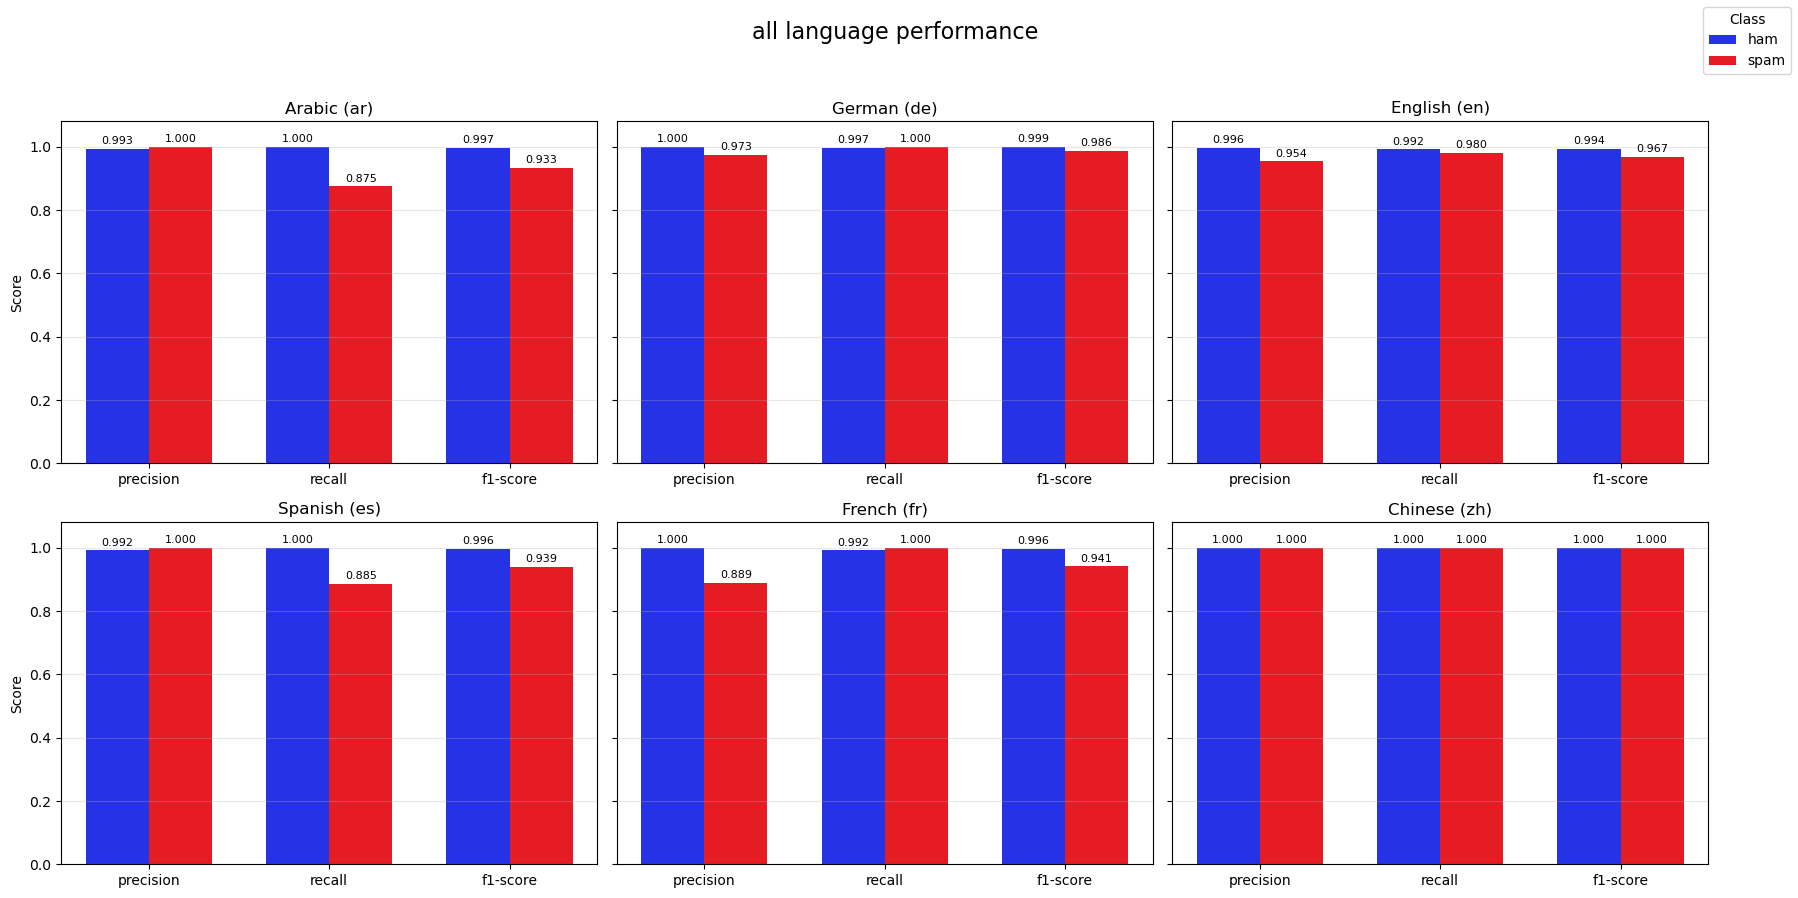

In [18]:
def get_prediction_frame_for_plot() -> pd.DataFrame:
    if "pred_ids" in globals() and "test_df" in globals():
        frame = test_df.copy().reset_index(drop=True)
        frame["pred_label_id"] = pred_ids
        frame["pred_label"] = frame["pred_label_id"].map(ID2LABEL)
        return frame

    predictions_path = MODEL_OUTPUT_DIR / "test_predictions.csv"
    if not predictions_path.exists():
        raise FileNotFoundError("Run evaluation first, or load an existing test_predictions.csv from the model output directory.")

    frame = pd.read_csv(predictions_path)
    if "label_id" not in frame.columns:
        frame["label_id"] = frame["label"].map(LABEL2ID).astype(int)
    if "pred_label_id" not in frame.columns:
        frame["pred_label_id"] = frame["pred_label"].map(LABEL2ID).astype(int)
    return frame

plot_df = get_prediction_frame_for_plot()
metric_names = ["precision", "recall", "f1-score"]
ordered_languages = [code for code in LANGUAGE_NAMES if code in set(plot_df["language_code"])]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
axes = axes.flatten()

for ax, language_code in zip(axes, ordered_languages):
    subset = plot_df[plot_df["language_code"] == language_code]
    y_true = subset["label_id"].to_numpy()
    y_pred = subset["pred_label_id"].to_numpy()
    language_report = classification_report(
        y_true,
        y_pred,
        target_names=[ID2LABEL[0], ID2LABEL[1]],
        output_dict=True,
        zero_division=0,
    )

    x = np.arange(len(metric_names))
    width = 0.35
    ham_scores = [language_report["ham"][metric] for metric in metric_names]
    spam_scores = [language_report["spam"][metric] for metric in metric_names]

    ham_bars = ax.bar(x - width / 2, ham_scores, width, label="ham", color="#2632E6")
    spam_bars = ax.bar(x + width / 2, spam_scores, width, label="spam", color="#E51C23")

    ax.set_title(f"{LANGUAGE_NAMES.get(language_code, language_code)} ({language_code})")
    ax.set_xticks(x)
    ax.set_xticklabels(["precision", "recall", "f1-score"])
    ax.set_ylim(0, 1.08)
    ax.grid(axis="y", alpha=0.3)
    ax.bar_label(ham_bars, fmt="%.3f", padding=2, fontsize=8)
    ax.bar_label(spam_bars, fmt="%.3f", padding=2, fontsize=8)

for ax in axes[len(ordered_languages):]:
    ax.axis("off")

axes[0].set_ylabel("Score")
axes[3].set_ylabel("Score")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", title="Class")
fig.suptitle("all language performance", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.96, 0.95])
plt.show()


## confusion matrix

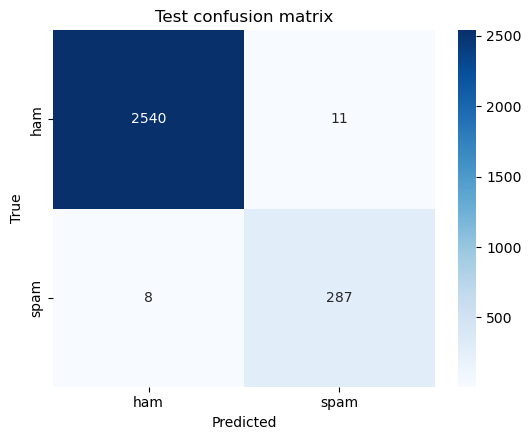

In [10]:
cm = confusion_matrix(true_ids, pred_ids, labels=[LABEL2ID["ham"], LABEL2ID["spam"]])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
try:
    import seaborn as sns
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["ham", "spam"],
        yticklabels=["ham", "spam"],
        ax=ax,
    )
except ImportError:
    ax.imshow(cm, cmap="Blues")
    for (row, col), value in np.ndenumerate(cm):
        ax.text(col, row, int(value), ha="center", va="center")
    ax.set_xticks([0, 1], ["ham", "spam"])
    ax.set_yticks([0, 1], ["ham", "spam"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Test confusion matrix")
plt.tight_layout()
plt.show()


In [16]:
def make_jsonable(value):
    if isinstance(value, dict):
        return {str(k): make_jsonable(v) for k, v in value.items()}
    if isinstance(value, list):
        return [make_jsonable(v) for v in value]
    if isinstance(value, tuple):
        return [make_jsonable(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    return value

for output_dir in [MODEL_OUTPUT_DIR, UI_MODEL_OUTPUT_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(output_dir, safe_serialization=True)
    tokenizer.save_pretrained(output_dir)

test_predictions = test_df.copy().reset_index(drop=True)
test_predictions["pred_label_id"] = pred_ids
test_predictions["pred_label"] = test_predictions["pred_label_id"].map(ID2LABEL)
test_predictions["ham_probability"] = probabilities[:, LABEL2ID["ham"]]
test_predictions["spam_probability"] = probabilities[:, LABEL2ID["spam"]]

metrics_bundle = {
    "base_model_source": model_source,
    "new_model_output_dir": str(MODEL_OUTPUT_DIR),
    "ui_model_output_dir": str(UI_MODEL_OUTPUT_DIR),
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_ratio": WARMUP_RATIO,
    "class_weights_ham_spam": class_weights.detach().cpu().tolist(),
    "training_history": history_df.to_dict(orient="records"),
    "validation_metrics": validation_metrics,
    "test_metrics": test_metrics,
    "classification_report": report_dict,
    "per_language_metrics": per_language_df.to_dict(orient="records"),
}

for artifact_dir in [MODEL_OUTPUT_DIR, UI_MODEL_OUTPUT_DIR]:
    with open(artifact_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(make_jsonable(metrics_bundle), f, ensure_ascii=False, indent=2)
    test_predictions.to_csv(artifact_dir / "test_predictions.csv", index=False, encoding="utf-8-sig")
    per_language_df.to_csv(artifact_dir / "per_language_metrics.csv", index=False, encoding="utf-8-sig")
    report_df.to_csv(artifact_dir / "classification_report.csv", encoding="utf-8-sig")

print(f"Saved multilingual model: {MODEL_OUTPUT_DIR}")
print(f"Saved UI model copy: {UI_MODEL_OUTPUT_DIR}")
print(f"Saved metrics: {MODEL_OUTPUT_DIR / 'metrics.json'}")
print(f"Original English model remains: {BASE_MODEL_PATH}")


Saved multilingual model: d:\Project\Leeds\Msc Project\local_artifacts\huggingface\models\finetuned_xlm_roberta_multilingual_sms_spam
Saved UI model copy: d:\Project\Leeds\Msc Project\Models\multilingual_transformer_spam_classifier
Saved metrics: d:\Project\Leeds\Msc Project\local_artifacts\huggingface\models\finetuned_xlm_roberta_multilingual_sms_spam\metrics.json
Original English model remains: d:\Project\Leeds\Msc Project\local_artifacts\huggingface\models\finetuned_xlm_roberta_sms_spam


In [15]:
@torch.inference_mode()
def predict_message(text, show_probability=False):
    model.eval()
    inputs = tokenizer(text, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
    inputs = {key: value.to(model.device) for key, value in inputs.items()}

    with amp_context():
        logits = model(**inputs).logits

    probabilities = torch.softmax(logits.float(), dim=-1)[0].detach().cpu().numpy()
    prediction_id = int(probabilities.argmax())
    prediction = ID2LABEL[prediction_id]

    if show_probability:
        probability_by_label = {
            ID2LABEL[index]: float(probability)
            for index, probability in enumerate(probabilities)
        }
        return prediction, probability_by_label

    return prediction

# test_text = "Congratulations! You have won a free prize. Reply now to claim it."
# test_text = "Congrats! Youve been selected for a remote task role. Earn daily income by rating hotels. Start today!"
# test_text = "Dear Customer your pyatm wallet Has been booked and hold Your amount please complete your kyc contact customer care 7044518857"
#test_text = "Your [chuanzhao li] verification code is: 123456. If you did not request this, secure your account here"
# test_text = "Herzlichen Glückwunsch, Sie haben einen Gutschein gewonnen. Jetzt Link öffnen!"
# test_text = "明天下午三点开会可以吗？"
test_text = "恭喜中奖，请点击链接领取现金红包。"
# test_text = "Félicitations, vous avez gagné un cadeau gratuit. Cliquez ici."
# test_text = "Has ganado un premio. Reclámalo ahora en este enlace."
# test_text = "لقد ربحت جائزة مجانية، اضغط على الرابط الآن للمطالبة بها."

prediction = predict_message(test_text)
print(prediction)


spam
